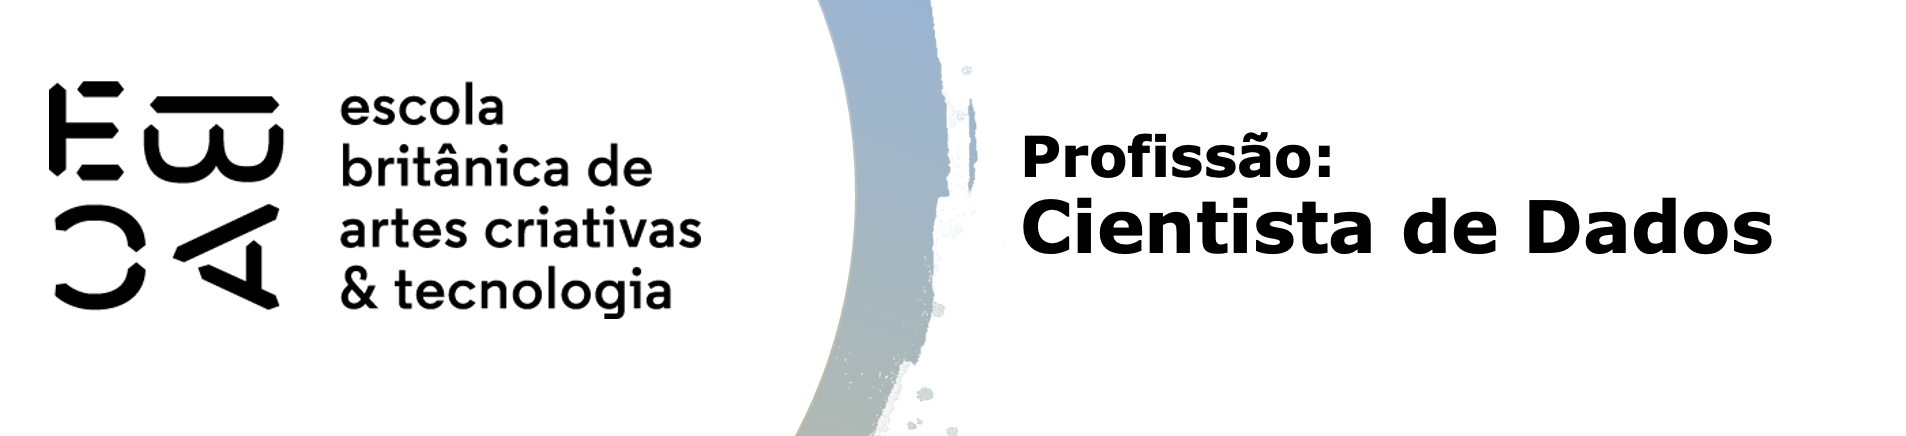

# Árvores II - Tarefa 3

### 1. Carregar as bases

Vamos utilizar nesta tarefa as bases de reconhecimento de atividade humana através do celular. Carregue novamente as bases salvas na tarefa I.

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [17]:
file_x_train = "./UCI HAR Dataset/x_train.csv"
file_x_test = "./UCI HAR Dataset/x_test.csv"

file_y_train = "./UCI HAR Dataset/train/Y_train.txt"
file_y_test = "./UCI HAR Dataset/test/Y_test.txt"

x_train = pd.read_csv(file_x_train)
x_test = pd.read_csv(file_x_test)

y_train = pd.read_csv(file_y_train, header=None)
y_test = pd.read_csv(file_y_test, header=None)


### 2. Calcule os ```ccp_alphas```. 

Vamos seguir uma lógica bem em linha com o que já estamso acostumados, com as seguintes orientações:

- Utilizar treinamento e teste conforme já vieram definidos originalmente
- Por pragmatismo, utilizar ```min_samples_leaf=20```
- Utilize as mesmas "3 melhores variáveis" identificadas no exercício anterior.

In [18]:
clf = DecisionTreeClassifier(random_state=2360873, min_samples_leaf=20).fit(x_train, y_train)

importances = clf.feature_importances_

top_features = sorted(range(len(importances)), key=lambda i: importances[i], reverse=True)[:3]

X_train_top = x_train.iloc[:, top_features]
X_test_top = x_test.iloc[:, top_features]

clf0 = DecisionTreeClassifier(random_state=42, min_samples_leaf=20)

path = clf0.cost_complexity_pruning_path(X_train_top, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

ccp_alphas_positive_unique = sorted(set(ccp_alphas[ccp_alphas > 0]))

### 3. *Grid Search*

Vou deixar especificações iniciais mínimas, que visam limitar o tempo de máquina, pois um procedimento desses pode demorar muito tempo dependendo da especificação. Mas conforme você for ficando confortável com o tempo consumido pelo procedimento, pode fazer um algoritmo mais exaustivo, por exemplo, avaliando mais valores de ```ccp_alpha```.

- Meça o tempo
- Utilize a base de treinamento
- Utilize um *cross validation* do tipo *k-fold*, especifique k=10
- Você pode ler 1 a cada ```k``` valores para uma melhor varredura utilizando, por exemplo, ```ccp_alpha[::10]```
- Não se esqueça de limitar o número de variáveis

In [19]:
%%time

ccp_alphas_sampled = ccp_alphas_positive_unique[::10]

grid_parametros = {'ccp_alpha':ccp_alphas_sampled}

grid = GridSearchCV(estimator = clf, param_grid=grid_parametros, cv=10, verbose=100)
grid.fit(X_train_top, y_train) 

Fitting 10 folds for each of 11 candidates, totalling 110 fits
[CV 1/10; 1/11] START ccp_alpha=6.599064264795887e-06...........................
[CV 1/10; 1/11] END ccp_alpha=6.599064264795887e-06;, score=0.753 total time=   0.0s
[CV 2/10; 1/11] START ccp_alpha=6.599064264795887e-06...........................
[CV 2/10; 1/11] END ccp_alpha=6.599064264795887e-06;, score=0.740 total time=   0.0s
[CV 3/10; 1/11] START ccp_alpha=6.599064264795887e-06...........................
[CV 3/10; 1/11] END ccp_alpha=6.599064264795887e-06;, score=0.804 total time=   0.0s
[CV 4/10; 1/11] START ccp_alpha=6.599064264795887e-06...........................
[CV 4/10; 1/11] END ccp_alpha=6.599064264795887e-06;, score=0.717 total time=   0.0s
[CV 5/10; 1/11] START ccp_alpha=6.599064264795887e-06...........................
[CV 5/10; 1/11] END ccp_alpha=6.599064264795887e-06;, score=0.727 total time=   0.0s
[CV 6/10; 1/11] START ccp_alpha=6.599064264795887e-06...........................
[CV 6/10; 1/11] END ccp_al

GridSearchCV(cv=10,
             estimator=DecisionTreeClassifier(min_samples_leaf=20,
                                              random_state=2360873),
             param_grid={'ccp_alpha': [np.float64(6.599064264795887e-06),
                                       np.float64(1.267011492539369e-05),
                                       np.float64(5.052075237058876e-05),
                                       np.float64(0.0001289558791748341),
                                       np.float64(0.00019373709993609307),
                                       np.float64(0.0003221807312819491),
                                       np.float64(0.0005618746315002835),
                                       np.float64(0.00081141201924662),
                                       np.float64(0.0012644530888405805),
                                       np.float64(0.0024277232304312597),
                                       np.float64(0.04371676659987836)]},
             verbose=100)

### 4. Avaliando a árvore

- Obtenha a árvore na melhor configuração treinada em toda a base de treino
- Calcule a acurácia dessa árvore na base de testes
- Visualize a matriz de confusão

In [20]:
resultados = pd.DataFrame(grid.cv_results_)
resultados.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.019269,0.001019,0.002706,0.000643,0.000007,{'ccp_alpha': 6.599064264795887e-06},0.752717,0.740489,0.804082,0.717007,0.726531,0.748299,0.772789,0.731973,0.836735,0.780952,0.761157,0.035701,6
1,0.019363,0.000612,0.002560,0.000492,0.000013,{'ccp_alpha': 1.267011492539369e-05},0.752717,0.740489,0.804082,0.717007,0.726531,0.748299,0.772789,0.731973,0.836735,0.780952,0.761157,0.035701,6
2,0.019629,0.001215,0.002701,0.000460,0.000051,{'ccp_alpha': 5.052075237058876e-05},0.752717,0.740489,0.804082,0.717007,0.726531,0.748299,0.772789,0.731973,0.836735,0.780952,0.761157,0.035701,6
3,0.019270,0.000829,0.002654,0.000747,0.000129,{'ccp_alpha': 0.0001289558791748341},0.752717,0.740489,0.801361,0.717007,0.726531,0.748299,0.772789,0.731973,0.836735,0.780952,0.760885,0.035381,9
4,0.019524,0.000524,0.002199,0.000399,0.000194,{'ccp_alpha': 0.00019373709993609307},0.755435,0.740489,0.798639,0.719728,0.726531,0.748299,0.772789,0.733333,0.836735,0.764626,0.759660,0.033995,10


In [21]:
melhor_ccp = resultados.iloc[grid.best_index_,4]

clf = DecisionTreeClassifier(random_state=2360873, ccp_alpha=melhor_ccp).fit(X_train_top, y_train)

y_test_pred = clf.predict(X_test_top)

In [22]:
clf.score(X_test_top, y_test)

0.7227689175432643

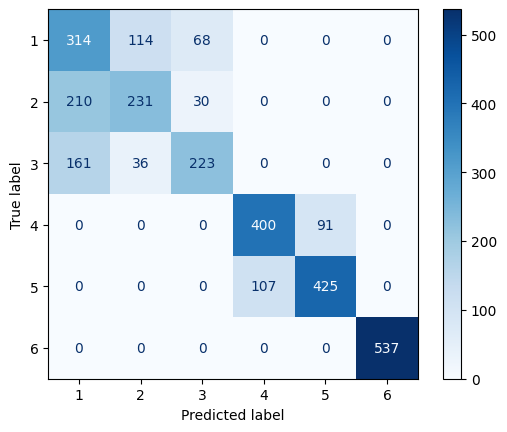

In [23]:
y_pred = clf.predict(X_test_top)

matriz_confusao = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao, display_labels=clf.classes_)
disp.plot(cmap='Blues')

### 5. Melhorando a árvore

A melhor forma de se melhorar um algoritmo é colocando nele novas variáveis que agreguem valor. Podemos usar a força-bruta e ir colocando variáveis aleatoriamente - ou colocar todas e deixar rodando por um bom tempo - ou utilizar uma lógica eficiente e fazer uma seleção de variáveis.

- Observe que há classes mais fáceis e mais difíceis de se identificar
- Crie uma variável binária para uma das classes de maior erro
- Faça uma árvore de classificação bem simples para esta variável:
    - utilize ```mean_samples_leaf=20```
    - utilize ```max_depth=4```
    - coloque todas as variáveis
- Observe a importância das variáveis, e selecione as 3 com maior importância
- Rode novamente o algoritmo acima com as 3 novas variáveis e avalie a acurácia

In [25]:
X_test_error = x_test.copy()
X_train_error = x_train.copy()

X_test_error['error_class'] = (y_test[0] == 1).astype(int).to_list()
X_train_error['error_class'] = (y_train[0] == 1).astype(int).to_list()

In [28]:
clf = DecisionTreeClassifier(random_state=2309, min_samples_leaf=20, max_depth=4)
clf.fit(X_train_error, y_train)


DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=2309)

In [32]:
importances = clf.feature_importances_
var = X_train_error.columns

df_importances = pd.DataFrame({'var': var, 'importancia': importances})
df_importances.sort_values(by='importancia', ascending=False).head(3)

,var,importancia
54,tGravityAcc-min()-X,0.261584
391,"fBodyAccJerk-bandsEnergy()-1,16",0.235051
563,error_class,0.220461


In [33]:
best_vars = df_importances.sort_values(by='importancia', ascending=False).iloc[0:3, 0].to_list()

In [34]:
X_train_new = X_train_error[best_vars]
X_test_new = X_test_error[best_vars]

In [40]:
path = clf.cost_complexity_pruning_path(X_train_new, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

ccp_alphas_positive_unique = sorted(set(ccp_alphas[ccp_alphas > 0]))

In [48]:
grid_parametros = {'ccp_alpha':ccp_alphas_positive_unique}
grid = GridSearchCV(estimator = clf, param_grid=grid_parametros, cv=10, verbose=100)
grid.fit(x_train, y_train) 

Fitting 10 folds for each of 7 candidates, totalling 70 fits
[CV 1/10; 1/7] START ccp_alpha=0.001292962275914909.............................
[CV 1/10; 1/7] END ccp_alpha=0.001292962275914909;, score=0.874 total time=   1.5s
[CV 2/10; 1/7] START ccp_alpha=0.001292962275914909.............................
[CV 2/10; 1/7] END ccp_alpha=0.001292962275914909;, score=0.826 total time=   1.5s
[CV 3/10; 1/7] START ccp_alpha=0.001292962275914909.............................
[CV 3/10; 1/7] END ccp_alpha=0.001292962275914909;, score=0.914 total time=   1.5s
[CV 4/10; 1/7] START ccp_alpha=0.001292962275914909.............................
[CV 4/10; 1/7] END ccp_alpha=0.001292962275914909;, score=0.720 total time=   1.5s
[CV 5/10; 1/7] START ccp_alpha=0.001292962275914909.............................
[CV 5/10; 1/7] END ccp_alpha=0.001292962275914909;, score=0.875 total time=   1.5s
[CV 6/10; 1/7] START ccp_alpha=0.001292962275914909.............................
[CV 6/10; 1/7] END ccp_alpha=0.0012929

GridSearchCV(cv=10,
             estimator=DecisionTreeClassifier(max_depth=4, min_samples_leaf=20,
                                              random_state=2309),
             param_grid={'ccp_alpha': [np.float64(0.001292962275914909),
                                       np.float64(0.002196779295309037),
                                       np.float64(0.02246683368460256),
                                       np.float64(0.06282957850495711),
                                       np.float64(0.1568756665281737),
                                       np.float64(0.1672577195777995),
                                       np.float64(0.1861382417305819)]},
             verbose=100)

In [49]:
resultados = pd.DataFrame(grid.cv_results_)
resultados.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,1.610421,0.008322,0.006451,0.000435,0.001293,{'ccp_alpha': 0.001292962275914909},0.873641,0.826087,0.914286,0.719728,0.874830,0.911565,0.923810,0.798639,0.887075,0.755102,0.848476,0.067144,3
1,1.610104,0.007560,0.006096,0.000357,0.002197,{'ccp_alpha': 0.002196779295309037},0.873641,0.826087,0.914286,0.719728,0.874830,0.911565,0.923810,0.798639,0.887075,0.755102,0.848476,0.067144,3
2,1.606426,0.006576,0.006391,0.000625,0.022467,{'ccp_alpha': 0.02246683368460256},0.883152,0.828804,0.919728,0.711565,0.865306,0.910204,0.922449,0.823129,0.887075,0.823129,0.857454,0.060783,1
3,1.608252,0.010805,0.006581,0.000607,0.062830,{'ccp_alpha': 0.06282957850495711},0.883152,0.828804,0.919728,0.711565,0.865306,0.910204,0.922449,0.823129,0.887075,0.823129,0.857454,0.060783,1
4,1.607256,0.007746,0.006581,0.000672,0.156876,{'ccp_alpha': 0.1568756665281737},0.544837,0.546196,0.544218,0.545578,0.544218,0.542857,0.544218,0.544218,0.544218,0.544218,0.544477,0.000856,5


In [50]:
melhor_ccp = resultados.iloc[grid.best_index_,4]

clf = DecisionTreeClassifier(random_state=2360873, ccp_alpha=melhor_ccp).fit(X_train_new, y_train)

Acurácia: 77.37%


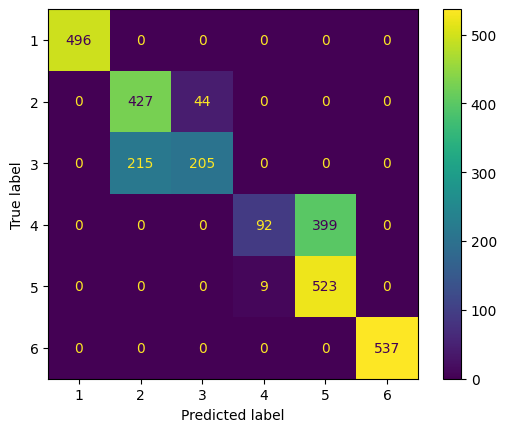

In [51]:
print(f'Acurácia: {clf.score(X_test_new,y_test)*100:.2f}%')
ConfusionMatrixDisplay.from_estimator(clf, X_test_new, y_test);